In [29]:
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import cv2

from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [30]:
# Define path variables
TRAIN_DATA_PATH = 'train.csv'
DATA_DIR = './train'

# Select the device to train on
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define hyperparameters
EPOCHS = 150        # number of epochs
LR = 0.001         # Learning rate
IMG_SIZE  = 512     # Size of image
BATCH_SIZE = 8    # Batch size 

In [31]:
df = pd.read_csv(TRAIN_DATA_PATH)

In [32]:
sample = df.iloc[np.random.randint(0, df.shape[0], size=5)]
def generate_sample_images(sample):
    imgs = sample.images
    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, image in enumerate(imgs):
        image = cv2.imread(image)
        print(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax[i].set_title("IMAGE")
        ax[i].imshow(image)

def generate_sample_masks(sample):
    masks = sample.masks

    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, mask in enumerate(masks):
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE) / 255.0

        ax[i].set_title("GROUND TRUTH")
        ax[i].imshow(mask, cmap='gray')

In [33]:
# Split data in separate train and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=57)

In [34]:
import albumentations as A

In [ ]:
# Define the augmentations
def get_train_augs():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),      # Horizontal Flip with 0.5 probability
        A.VerticalFlip(p=0.5)         # Vertical Flip with 0.5 probability
    ], is_check_shapes=False)

def get_val_augs():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE)
    ], is_check_shapes=False)

In [36]:
from torch.utils.data import Dataset

In [ ]:
# Create a custom dataset class
class SegmentationDataset(Dataset):
    def __init__(self, df, augs):
        self.df = df
        self.augs = augs

    def __len__(self):
        """读取样本数量"""
        return len(self.df)

    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        image = sample.images
        mask = sample.masks
        
        # Read images and masks
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)
        mask = np.expand_dims(mask, axis=-1)
        
        # print(f"Shapes of images before augmentation: {image.shape}")
        # print(f"Shapes of masks before augmentation: {mask.shape}")
        
        # Apply augmentations
        if self.augs:
            data = self.augs(image=image, mask=mask)
            image = data['image']
            mask = data['mask']
            
        # print(f"\nShapes of images after augmentation: {image.shape}")
        # print(f"Shapes of masks after augmentation: {mask.shape}")
        # print(torch.tensor(image))
        # Transpose image dimensions in pytorch format
        # (H,W,C) -> (C,H,W)
        image = np.transpose(image, (2,0,1)).astype(np.float32)
        mask = np.transpose(mask, (2,0,1)).astype(np.float32)
        
        # Normalize the images and masks 
        image = torch.Tensor(image) / 255.0    
        mask = torch.round(torch.Tensor(mask) / 255.0)

        return image, mask

In [38]:
# Processed train and validation sets
train_data = SegmentationDataset(train_df, get_train_augs())
val_data = SegmentationDataset(val_df, get_val_augs())

In [39]:
len(train_data), len(val_data)

(1673, 419)

In [40]:
from torch.utils.data import DataLoader

In [41]:
trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)


In [ ]:

import random
def set_seed(seed):
    random.seed(seed)  
    np.random.seed(seed)  
    torch.manual_seed(seed)  
    torch.cuda.manual_seed(seed)  
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True  
    torch.backends.cudnn.benchmark = False  


set_seed(42) 

In [ ]:
from TransUnet.vit_seg_modeling import VisionTransformer as RCSnet
from TransUnet.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

config_ueformer = CONFIGS_ViT_seg['R50-ViT-B_16']
input_size=512
DEVICE = "cuda"
config_ueformer.n_classes = 1
config_ueformer.n_skip = 3
config_ueformer.patches.grid = (int(input_size / 16), int(input_size / 16))
ueformer = RCSnet(config_ueformer, input_size, num_classes=1).to(DEVICE)


In [ ]:
# Load best model
ueformer.load_state_dict(torch.load("./BestModel150epoch/best_model_ema_feat2.pt"))

# Function to output the prediction mask
def make_inference(idx):
    image, mask = val_data[idx]
    logits_mask = ueformer(image.to(DEVICE).unsqueeze(0)) # (C, H, W) -> (1, C, H, W)

    # Predicted mask
    pred_mask = torch.sigmoid(logits_mask) 
    pred_mask = (pred_mask > 0.5) * 1.0
    
    return image, mask, pred_mask

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3785859511.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ueformer.load_state_dict(torch.load("./BestModel150epoch/be

In [49]:
from TransUnet8.vit_seg_modeling import VisionTransformer as TransUNet
from TransUnet8.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

config_transunet = CONFIGS_ViT_seg['R50-ViT-B_16']
input_size=512
DEVICE = "cuda"
config_transunet.n_classes = 1
config_transunet.n_skip = 3
config_transunet.patches.grid = (int(input_size / 16), int(input_size / 16))
# model = TransUNet(config_transunet, input_size, num_classes=1).cuda() ## TransUnet model
transunet = TransUNet(config_transunet, input_size, num_classes=1).to(DEVICE)

# Load best model
transunet.load_state_dict(torch.load("./BestModel150epoch/best_model_TUnet_8.pt"))


C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\429216363.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transunet.load_state_dict(torch.load("./BestModel150epoch/b

<All keys matched successfully>

In [50]:
# Define pretrained encoder model and weights
ENCODER = 'resnet101'
WEIGHTS = 'imagenet'

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

class FPNModel(nn.Module):
    def __init__(self):
        super(FPNModel, self).__init__()

        self.model = smp.FPN(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = FPNModel()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_FPN.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\2516906089.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best

<All keys matched successfully>

In [51]:
class DeeplabV3Model(nn.Module):
    def __init__(self):
        super(DeeplabV3Model, self).__init__()

        self.model = smp.DeepLabV3(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = DeeplabV3Model()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_DeeplabV3.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\2078067403.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best

<All keys matched successfully>

In [52]:
class MAnetModel(nn.Module):
    def __init__(self):
        super(MAnetModel, self).__init__()

        self.model = smp.MAnet(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = MAnetModel()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_MAnet.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\1411608593.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best

<All keys matched successfully>

In [53]:
class PSPNetModel(nn.Module):
    def __init__(self):
        super(PSPNetModel, self).__init__()

        self.model = smp.PSPNet(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = PSPNetModel()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_PSPnet.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3850911513.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best

<All keys matched successfully>

In [54]:
class UnetModel(nn.Module):
    def __init__(self):
        super(UnetModel, self).__init__()

        self.model = smp.Unet(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = UnetModel()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_Unet.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\1104104111.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best

<All keys matched successfully>

In [55]:
class UnetPlusModel(nn.Module):
    def __init__(self):
        super(UnetPlusModel, self).__init__()

        self.model = smp.UnetPlusPlus(
            encoder_name=ENCODER,
            encoder_weights=WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None)

    def forward(self, images, masks=None):
        logits = self.model(images)

        if masks != None:
            loss1 = DiceLoss(mode='binary')(logits, masks)
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            return logits, loss1 + loss2

        return logits

model = UnetPlusModel()
model.to(DEVICE)
model.eval()

# Load best model
model.load_state_dict(torch.load("./BestModel150epoch/best_model_Unet++.pt"))

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\633737088.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./BestModel150epoch/best_

<All keys matched successfully>

多个模型预测对比

C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3924288138.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))
C:\Users\hej

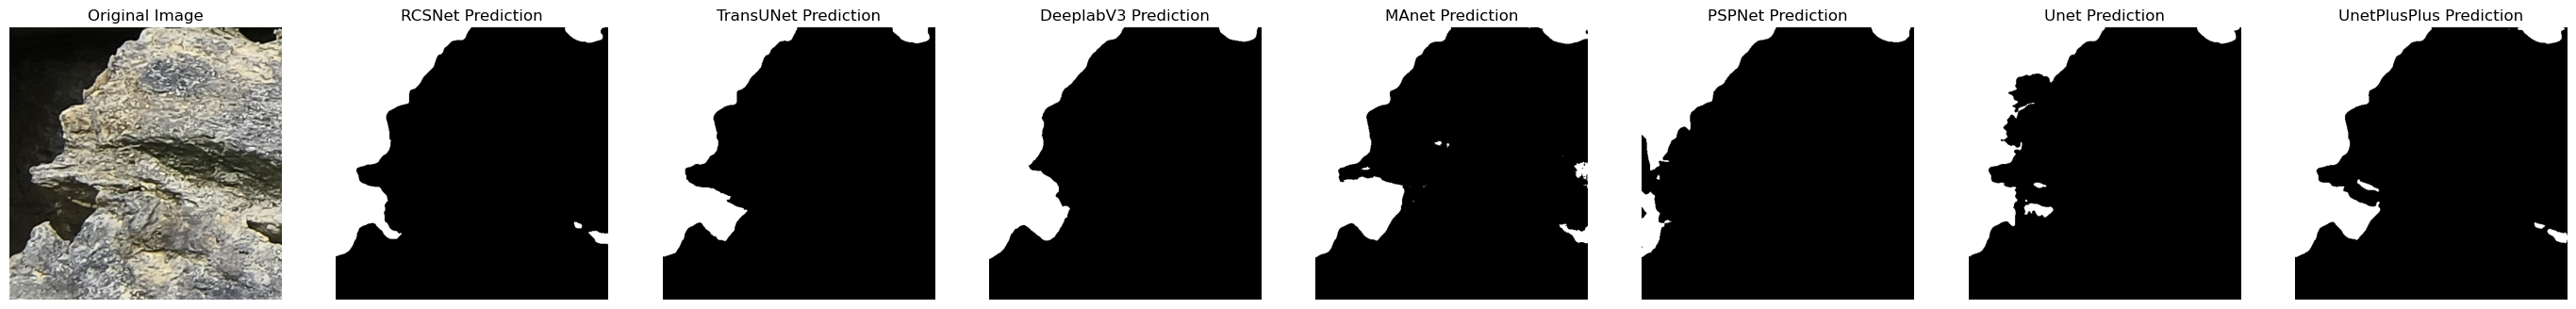

In [ ]:


model_infos = [
    {
        "name": "RCSNet",
        "type": "ueformer",
        "path": "./BestModel150epoch/best_model_ema_feat2.pt"
    },
    {
        "name": "TransUNet",
        "type": "transunet",
        "path": "./BestModel150epoch/best_model_TUnet_8.pt"
    },
    {
        "name": "DeeplabV3",
        "type": "deeplabv3",
        "path": "./BestModel150epoch/best_model_DeeplabV3.pt"
    },
    {
        "name": "MAnet",
        "type": "manet",
        "path": "./BestModel150epoch/best_model_MAnet.pt"
    },
    {
        "name": "PSPNet",
        "type": "pspnet",
        "path": "./BestModel150epoch/best_model_PSPnet.pt"
    },
    {
        "name": "Unet",
        "type": "unet",
        "path": "./BestModel150epoch/best_model_Unet.pt"
    },
    {
        "name": "UnetPlusPlus",
        "type": "unetplusplus",
        "path": "./BestModel150epoch/best_model_Unet++.pt"
    }
    

]


def load_model(model_type, model_path):
    if model_type == "ueformer":
        config_ueformer = CONFIGS_ViT_seg['R50-ViT-B_16']
        input_size = 512
        config_ueformer.n_classes = 1
        config_ueformer.n_skip = 3
        config_ueformer.patches.grid = (int(input_size / 16), int(input_size / 16))
        model = UEfomer(config_ueformer, input_size, num_classes=1).to(DEVICE).cuda()
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "transunet":
        config_transunet = CONFIGS_ViT_seg['R50-ViT-B_16']
        input_size=512
        config_transunet.n_classes = 1
        config_transunet.n_skip = 3
        config_transunet.patches.grid = (int(input_size / 16), int(input_size / 16))
        model = TransUNet(config_transunet, input_size, num_classes=1).to(DEVICE).cuda()
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "deeplabv3":
        model = DeeplabV3Model().to(DEVICE)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "manet":
        model = MAnetModel().to(DEVICE)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "pspnet":
        model = PSPNetModel().to(DEVICE)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "unet":
        model = UnetModel().to(DEVICE)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    elif model_type == "unetplusplus":
        model = UnetPlusModel().to(DEVICE)
        model.load_state_dict(torch.load(model_path))
        model.eval()
        return model
    else:
        raise ValueError("Unknown model type")

def predict_with_model(model, model_type, image_path):
    image = preprocess_image(image_path).to(DEVICE)
    with torch.no_grad():
        if model_type == "ueformer":
            logits_mask = model(image)
        elif model_type == "transunet":
            logits_mask = model(image)
        elif model_type == "deeplabv3":
            logits_mask = model(image)
        elif model_type == "manet":
            logits_mask = model(image)
        elif model_type == "pspnet":
            logits_mask = model(image)
        elif model_type == "unet":
            logits_mask = model(image)
        elif model_type == "unetplusplus":
            logits_mask = model(image)
        else:
            raise ValueError("Unknown model type")
        pred_mask = torch.sigmoid(logits_mask)
        pred_mask = (pred_mask > 0.5).float()
    return pred_mask.cpu().numpy()

image_path = "./train/images/0057.jpg"
plt.figure(figsize=(5 * len(model_infos), 5))
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

for idx, info in enumerate(model_infos):
    model = load_model(info["type"], info["path"])
    pred_mask = predict_with_model(model, info["type"], image_path)
    
    # 原图
    if idx == 0:
        plt.subplot(1, len(model_infos) + 1, 1)
        plt.imshow(original_image)
        plt.title("Original Image")
        plt.axis("off")
    
    # 预测图
    plt.subplot(1, len(model_infos) + 1, idx + 2)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title(f"{info['name']} Prediction")
    plt.axis("off")

plt.show()
# ...existing code...

读取测试集并保存

In [ ]:


import os
import shutil

def save_testset_from_df(df, out_dir=r'./saved_testset', indices=None, sample_n=None):
    images_dir = os.path.join(out_dir, 'images')
    masks_dir = os.path.join(out_dir, 'masks')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)

    if sample_n is not None:
        indices = np.random.choice(len(df), sample_n, replace=False)
    elif indices is None:
        indices = range(len(df))

    saved = 0
    skipped = 0
    for idx in indices:
        try:
            row = df.iloc[idx]
        except Exception:
            skipped += 1
            continue

        img_path = row['images']
        mask_path = row['masks']

        if not (os.path.exists(img_path) and os.path.exists(mask_path)):
            print(f"Warning: missing file for idx={idx}: {img_path} or {mask_path}")
            skipped += 1
            continue


        img_name = os.path.basename(img_path)
        mask_name = os.path.basename(mask_path)


        try:
            shutil.copy2(img_path, os.path.join(images_dir, img_name))
            shutil.copy2(mask_path, os.path.join(masks_dir, mask_name))
            saved += 1
        except Exception as e:
            print(f"Error copying idx={idx}: {e}")
            skipped += 1

    print(f"Saved {saved} samples, skipped {skipped}. Output dir: {os.path.abspath(out_dir)}")
    return {'saved': saved, 'skipped': skipped}


save_testset_from_df(val_df, out_dir=r'./saved_testset')


Saved 419 samples, skipped 0. Output dir: d:\pythoncode\paper\FractureIdentification-jupyter\jupyter\TansUnet\TranUnet_code\saved_testset


{'saved': 419, 'skipped': 0}

Loading RCSNet ...


C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3924288138.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Loading TransUNet ...


C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3924288138.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Loading DeeplabV3 ...


...

Loading Unet ...


C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3924288138.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Loading UnetPlusPlus ...


C:\Users\hejie\AppData\Local\Temp\ipykernel_326020\3924288138.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Using mask 0367.png for image 0367.jpg
Using mask 1892.png for image 1892.jpg
Using mask 0704.png for image 0704.jpg
Using mask 0243.png for image 0243.jpg
Using mask 1140.png for image 1140.jpg
Using mask 1133.png for image 1133.jpg
Saved figure to d:\pythoncode\paper\FractureIdentification-jupyter\jupyter\TansUnet\TranUnet_code\compare4.svg


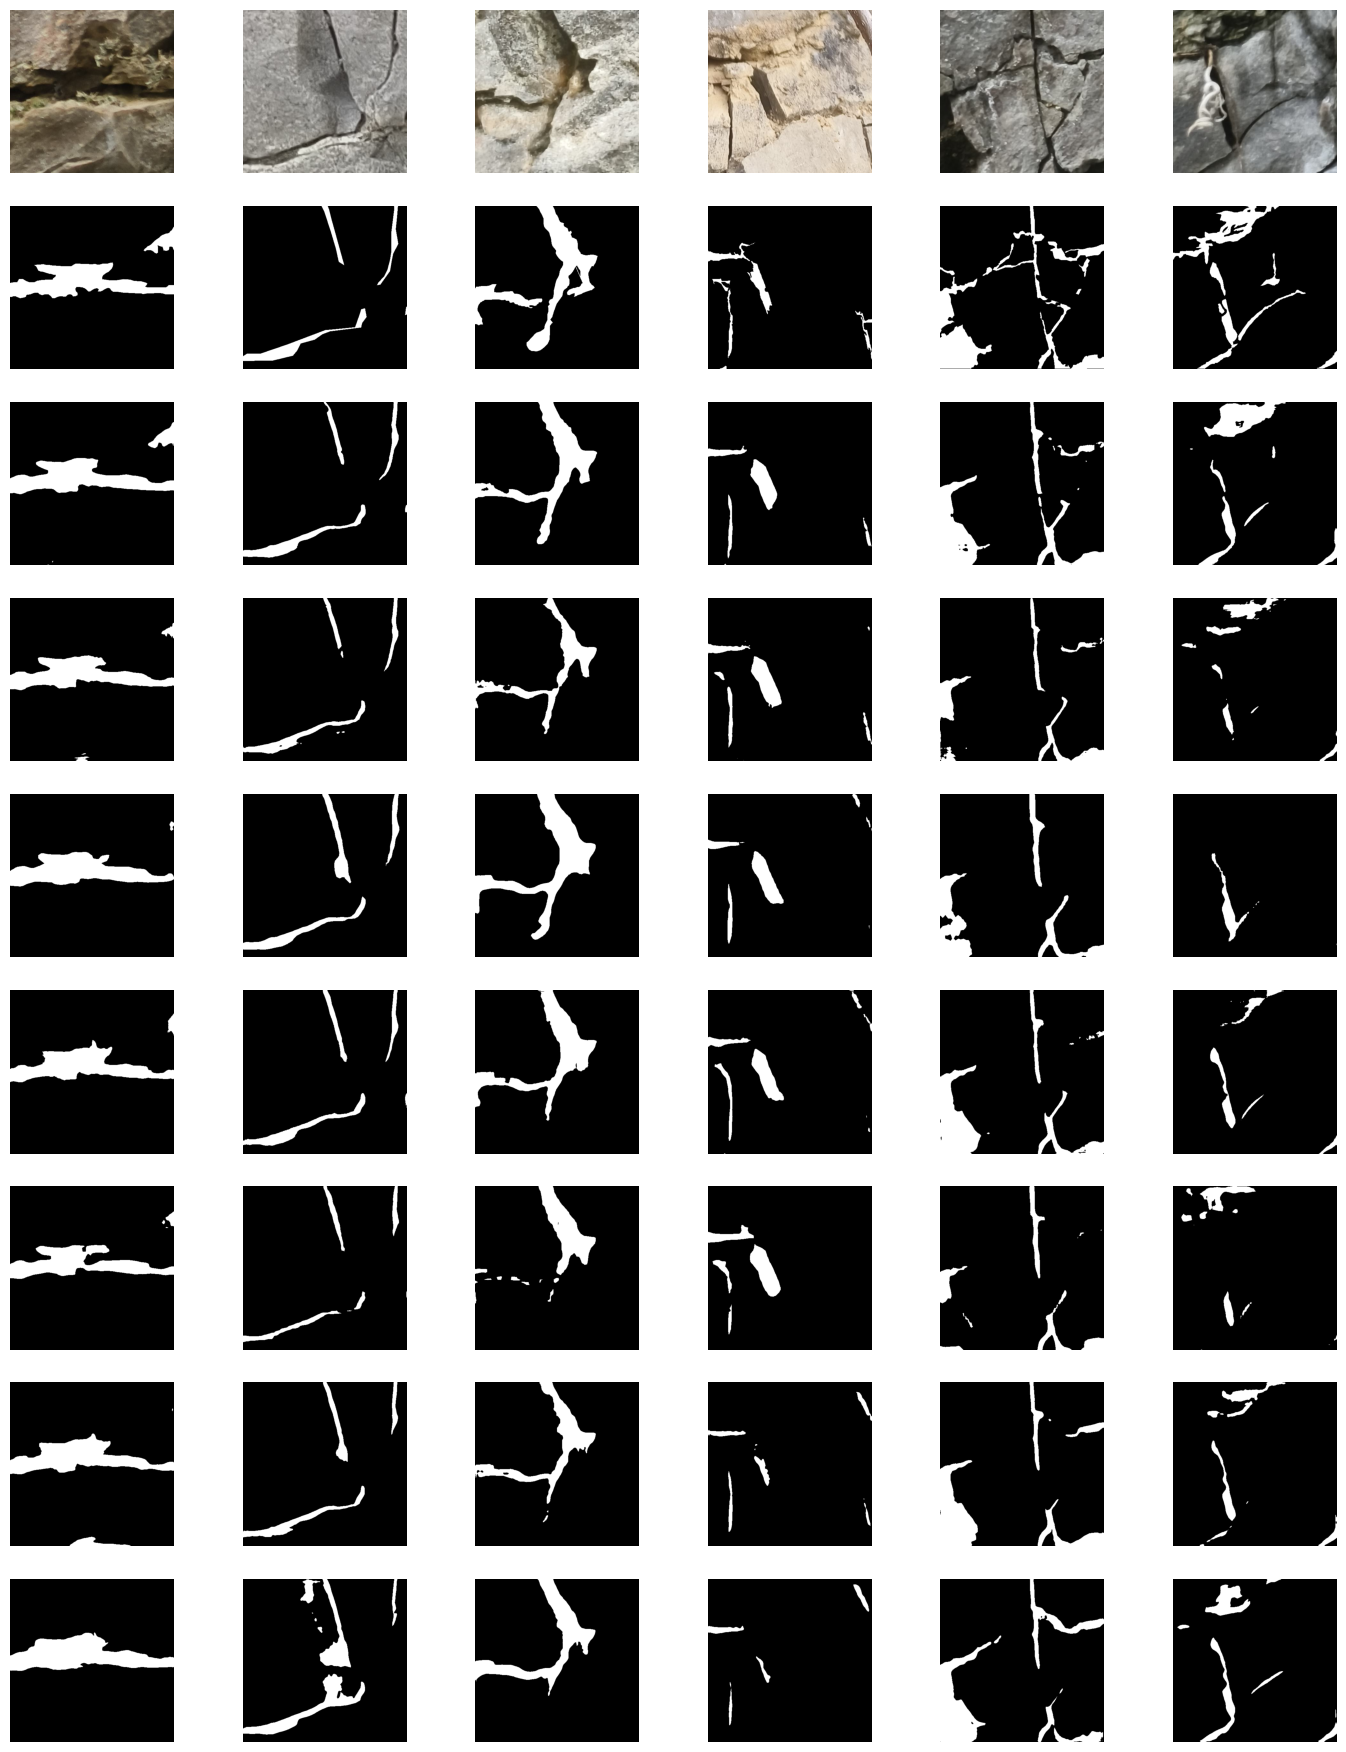

In [ ]:
# ...existing code...
import glob
import random

def predict_and_visualize_batch(saved_dir=r'./saved_testset',
                                 filenames=None,
                                 model_infos=model_infos,
                                 out_fig_path=None,
                                 device=DEVICE,
                                 img_size=IMG_SIZE,
                                 n_images=None,
                                 random_seed=42):

    images_dir = os.path.join(saved_dir, 'images')
    masks_dir = os.path.join(saved_dir, 'masks')
    assert os.path.isdir(images_dir), f"Images dir not found: {images_dir}"
    if not os.path.isdir(masks_dir):
        print(f"Warning: masks dir not found: {masks_dir} (will show empty GTs)")

    all_files = sorted(os.listdir(images_dir))
    if filenames:
        files = [f for f in filenames if f in all_files]
    elif n_images is not None:
        random.seed(random_seed)
        if n_images > len(all_files):
            print(f"requested n_images={n_images} larger than available {len(all_files)}; using all files.")
            files = all_files
        else:
            files = random.sample(all_files, n_images)
    else:
        files = all_files

    if len(files) == 0:
        print("No files to process.")
        return

    # load models once
    loaded = []
    for info in model_infos:
        print(f"Loading {info['name']} ...")
        m = load_model(info['type'], info['path'])
        loaded.append((info['name'], info['type'], m))

    n_images = len(files)
    n_models = len(loaded)

    originals = []
    gts = []
    all_preds = [ [] for _ in range(n_models) ]

    for fname in files:
        img_path = os.path.join(images_dir, fname)
        orig = cv2.imread(img_path)
        if orig is None:
            print(f"Cannot read image {img_path}, skipping.")
            continue
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        originals.append(orig)

        gt = None
        expected_mask = os.path.join(masks_dir, fname)
        if os.path.exists(expected_mask):
            gt = cv2.imread(expected_mask, cv2.IMREAD_GRAYSCALE)
        else:
            stem = os.path.splitext(fname)[0]
            candidates = glob.glob(os.path.join(masks_dir, stem + '.*'))
            if candidates:
                gt = cv2.imread(candidates[0], cv2.IMREAD_GRAYSCALE)
                print(f"Using mask {os.path.basename(candidates[0])} for image {fname}")
            else:
                if os.path.isdir(masks_dir):
                    print(f"No mask for {fname} in {masks_dir}")

        if gt is not None:
            if gt.ndim == 3:
                gt = cv2.cvtColor(gt, cv2.COLOR_BGR2GRAY)
            if (gt.shape[0], gt.shape[1]) != (img_size, img_size):
                gt = cv2.resize(gt, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
            gts.append(gt)
        else:
            gts.append(None)


        for m_idx, (m_name, m_type, m_model) in enumerate(loaded):
            pred = predict_with_model(m_model, m_type, img_path)
            pred = np.array(pred)
            if pred.ndim > 2:
                pred = np.squeeze(pred)

            if pred.shape != (img_size, img_size):
                pred_resized = cv2.resize((pred * 255).astype(np.uint8), (img_size, img_size), interpolation=cv2.INTER_NEAREST)
                pred_bin = (pred_resized > 127).astype(np.uint8)
            else:
                pred_bin = (pred > 0.5).astype(np.uint8)
            all_preds[m_idx].append(pred_bin)


    rows = 2 + n_models
    cols = n_images
    figsize = (max(4, cols * 3), max(3, rows * 2.5))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.expand_dims(axes, 0)
    elif cols == 1:
        axes = np.expand_dims(axes, 1)

    for c in range(cols):

        ax = axes[0, c]
        ax.imshow(originals[c])
        ax.axis('off')
        #if c == 0:
            #ax.set_title("Original", fontsize=12)

        # GT
        ax = axes[1, c]
        if gts[c] is not None:
            ax.imshow(gts[c], cmap='gray')
        else:
            ax.imshow(np.zeros((img_size, img_size)), cmap='gray')
        ax.axis('off')
        #if c == 0:
            #ax.set_title("GT Mask", fontsize=12)

    for m_idx, (m_name, _, _) in enumerate(loaded):
        row = 2 + m_idx
        for c in range(cols):
            ax = axes[row, c]
            pred = all_preds[m_idx][c]
            ax.imshow(pred, cmap='gray')
            ax.axis('off')
            #if c == 0:
                #ax.set_title(m_name, fontsize=12)
    #plt.tight_layout()
    fig.subplots_adjust(wspace=0.001, hspace=0.2)   
    
    if out_fig_path:
        fig.savefig(out_fig_path, bbox_inches='tight', dpi=200)
        print(f"Saved figure to {os.path.abspath(out_fig_path)}")
    plt.show()
    plt.close(fig)

predict_and_visualize_batch(saved_dir='./saved_testset', filenames=['0367.jpg','1892.jpg','0704.jpg','0243.jpg','1140.jpg','1133.jpg'], model_infos=model_infos, out_fig_path='compare4.svg')
